In [1]:
from pathlib import Path
import sys

# Add project root (.../CPSC_440_Project) to import path
sys.path.append(str(Path.cwd().parent))

from Utils.preprocess import preprocess_data
from Visuals.visuals import draw_ellipse
from Models.Gaussian import gaussian_model
from Models.GaussianMixture import gaussian_mixture_model
from Models.EneryDistance import gmm_energy_distance
from Models.TrainGaussian import train_gaussian_mixture
from Visuals.visuals import plot_gmm_dispersion, plot_gmm_heat
from Visuals.visuals import plot_gmm_samples

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.model_selection import train_test_split


In [2]:
dataset = preprocess_data()
dataset.head()

Combined dataset shape: (1633, 4)


,Name,Club,X,Y
0,Ryan,I7,-23.2,180.3
1,Ryan,I7,38.4,141.7
2,Ryan,I7,6.3,153.6
3,Ryan,I7,-7.6,49.7
4,Ryan,I7,11.2,162.1


In [3]:
counts_by_name_club = (
    dataset.groupby(["Name", "Club"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

counts_by_name_club

,Name,Club,count
0,5,W1,340
1,2,W1,190
2,3,I7,166
3,3,W1,154
4,6,W1,142
5,4,W1,125
6,8,W1,90
7,1,W1,87
8,2,I7,82
9,1,I9,75


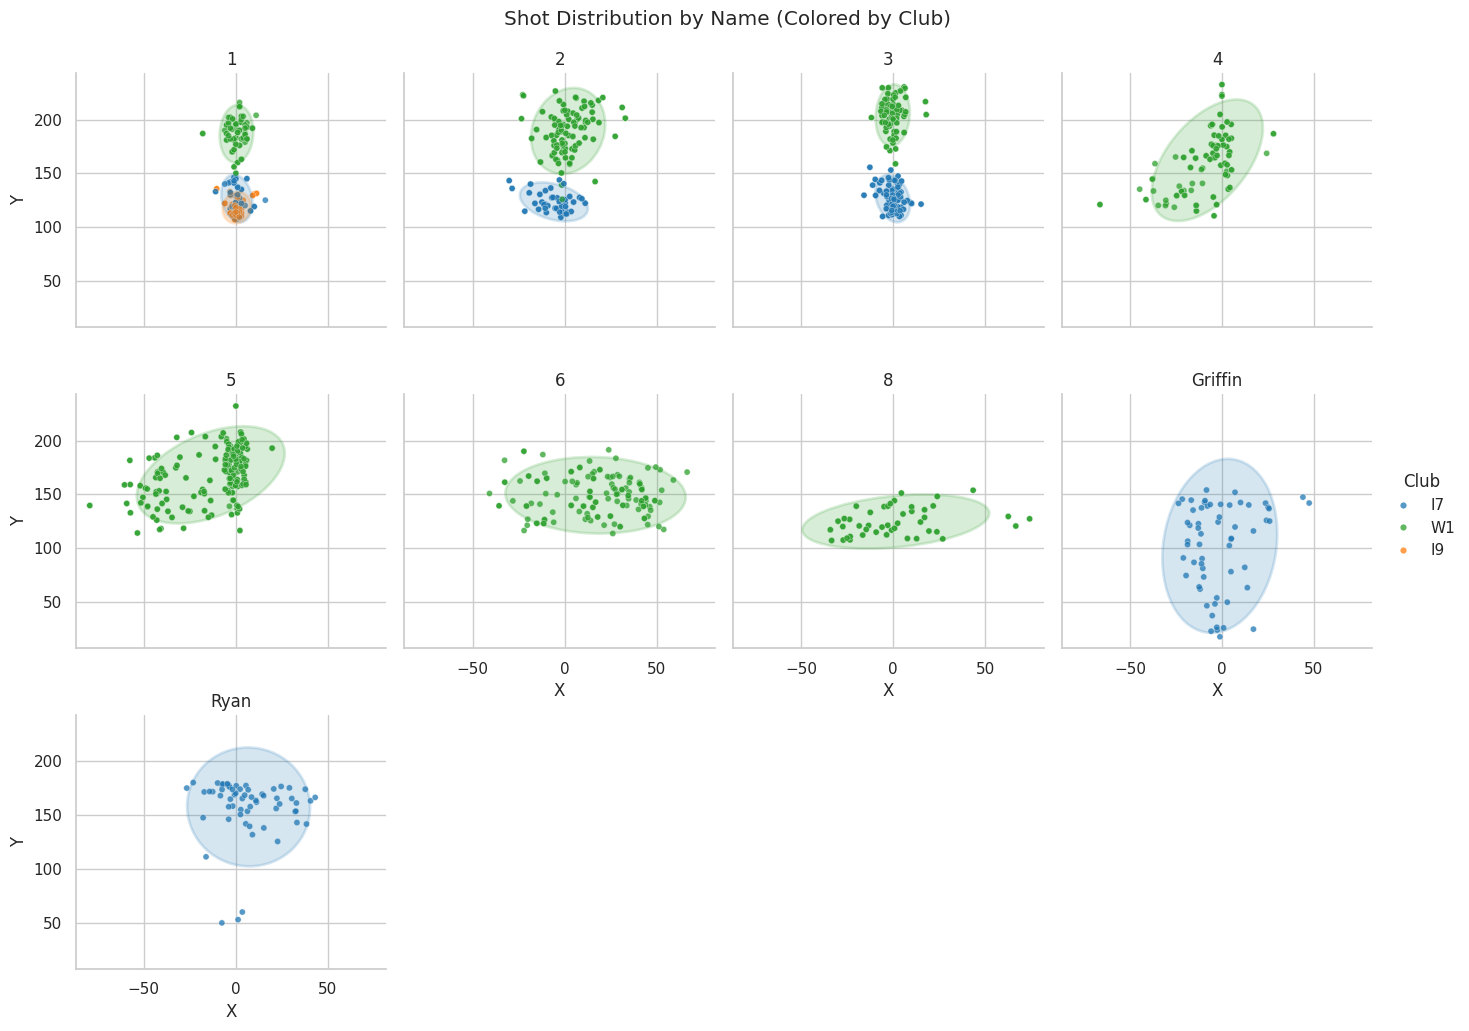

In [4]:


sns.set_theme(style="whitegrid")

plot_data = dataset.copy()
plot_data["Name"] = plot_data["Name"].astype(str)
plot_data["Club"] = plot_data["Club"].astype(str)
plot_data["X"] = plot_data["X"].astype(float)
plot_data["Y"] = plot_data["Y"].astype(float)

name_order = sorted(plot_data["Name"].dropna().unique())
club_order = sorted(plot_data["Club"].dropna().unique())
col_wrap = min(4, max(1, len(name_order)))
club_palette = dict(zip(club_order, sns.color_palette("tab10", n_colors=len(club_order))))


def covariance_ellipse(mean, covariance, n_std=2.0, **kwargs):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(eigenvalues, 0))
    return Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=True,
        **kwargs,
    )


g = sns.relplot(
    data=plot_data,
    x="X",
    y="Y",
    hue="Club",
    palette=club_palette,
    col="Name",
    col_order=name_order,
    col_wrap=col_wrap,
    kind="scatter",
    alpha=0.75,
    s=20,
    height=3.5,
    aspect=1,
    facet_kws={"sharex": True, "sharey": True},
)

for name, ax in g.axes_dict.items():
    subset_by_name = plot_data[plot_data["Name"] == name]
    for club, club_df in subset_by_name.groupby("Club"):
        if len(club_df) < 2:
            continue
        mean, covariance = gaussian_model(club_df["X"], club_df["Y"])
        ellipse = covariance_ellipse(
            mean,
            covariance,
            n_std=2.0,
            edgecolor=club_palette[club],
            facecolor=club_palette[club],
            linewidth=2,
            alpha=0.18,
        )
        ax.add_patch(ellipse)

g.set_axis_labels("X", "Y")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Shot Distribution by Name (Colored by Club)")
plt.show()

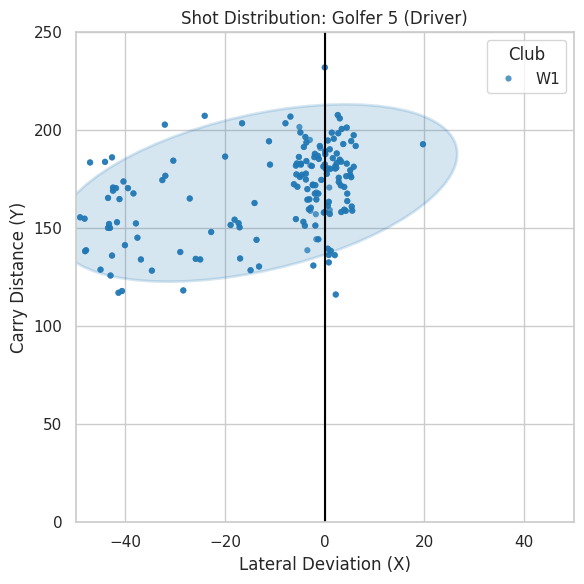

In [5]:
## This cell copilot
sns.set_theme(style="whitegrid")

target_golfer = "5"
plot_data = dataset.copy()
plot_data["Name"] = plot_data["Name"].astype(str)
plot_data["Club"] = plot_data["Club"].astype(str)
plot_data["X"] = plot_data["X"].astype(float)
plot_data["Y"] = plot_data["Y"].astype(float)

golfer_data = plot_data[plot_data["Name"] == target_golfer].dropna(subset=["X", "Y"]).copy()

club_order = sorted(golfer_data["Club"].dropna().unique())
club_palette = dict(zip(club_order, sns.color_palette("tab10", n_colors=len(club_order))))

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=golfer_data,
    x="X",
    y="Y",
    hue="Club",
    palette=club_palette,
    alpha=0.75,
    s=20,
    ax=ax,
    legend=True,
    edgecolor=None,
    linewidth=0,
    zorder=2,
 )

for club, club_df in golfer_data.groupby("Club"):
    if len(club_df) < 2:
        continue
    mean, covariance = gaussian_model(club_df["X"], club_df["Y"] )
    ellipse = covariance_ellipse(
        mean,
        covariance,
        n_std=2.0,
        edgecolor=club_palette[club],
        facecolor=club_palette[club],
        linewidth=2,
        alpha=0.18,
    )
    ax.add_patch(ellipse)

ax.axvline(x=0, color="black", linewidth=1.5, linestyle="-")
ax.set_xlim(-50, 50)
ax.set_ylim(0, 250)
ax.set_xlabel("Lateral Deviation (X)")
ax.set_ylabel("Carry Distance (Y)")
ax.set_title(f"Shot Distribution: Golfer 5 (Driver)")
plt.tight_layout()
plt.show()

In [6]:
ryan_data = dataset[dataset["Name"] == "Ryan"].dropna(subset=["X", "Y"]).copy()
idx, gmms, model_scores = train_gaussian_mixture(ryan_data)
idx

3

In [7]:
plot_gmm_dispersion(gmms,idx,ryan_data,"Ryan")

In [8]:
from Visuals.visuals import plot_gmm_samples


names = ["1", "2", "3", "4", "5", "6", "8", "Ryan", "Griffin"]

for name in names:
    name_data = dataset[dataset["Name"] == name].dropna(subset=["X", "Y", "Club"]).copy()
    if len(name_data) < 2:
        print(f"Not enough data for {name} to train GMM.")
        continue

    for club, club_data in name_data.groupby("Club"):
        club_data = club_data.dropna(subset=["X", "Y"]).copy()

        if len(club_data) < 2:
            print(f"Not enough data for {name}-{club} to train GMM.")
            continue

        max_components = min(8, len(club_data) - 1)
        idx, gmms, model_scores = train_gaussian_mixture(club_data, max_components=max_components)

        output_name = f"{name}_{club}".replace("/", "-").replace(" ", "_")
        plot_gmm_dispersion(gmms, idx, club_data, output_name)
        plot_gmm_heat(gmms, idx, club_data, output_name)
        plot_gmm_samples(gmms, idx, club_data, output_name, n_samples=100, include_idx0_panel=True)
        plot_gmm_samples(gmms, 0, club_data, output_name, n_samples=100)
        print(
            f"Saved plots for {name}-{club}: best_idx={idx}, models={len(gmms)}"
        )

/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/Visuals/visuals.py:185: UserWarning: Log scale: values of z <= 0 have been masked
  heat = ax.contourf(


Saved plots for 1-I7: best_idx=7, models=8


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/Visuals/visuals.py:185: UserWarning: Log scale: values of z <= 0 have been masked
  heat = ax.contourf(


Saved plots for 1-I9: best_idx=7, models=8


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/Visuals/visuals.py:185: UserWarning: Log scale: values of z <= 0 have been masked
  heat = ax.contourf(


...

Saved plots for 8-W1: best_idx=7, models=8


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


Saved plots for Ryan-I7: best_idx=3, models=8


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


Saved plots for Griffin-I7: best_idx=3, models=8
